In [1]:
print("Hello")

Hello


In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import VideoMAEImageProcessor, AutoImageProcessor
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os
import gc
from torchvision import transforms
import timm

2025-10-18 07:28:55.414326: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760772535.612828      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760772535.665915      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `ty

Using device: cuda
GPU: Tesla P100-PCIE-16GB
Available memory: 17.06 GB
foul: Found 300 videos
foul: Selected 300 videos
goal: Found 211 videos
goal: Selected 300 videos
freekick: Found 374 videos
freekick: Selected 300 videos
penalty: Found 322 videos
penalty: Selected 300 videos
corner: Found 411 videos
corner: Selected 300 videos

Total videos: 1500 (300 per class)

Dataset Split:
Train: 1200 videos
Val: 300 videos

Loading swin_small_patch4_window7_224...


model.safetensors:   0%|          | 0.00/200M [00:00<?, ?B/s]

Total parameters: 60,360,335
Trainable parameters: 60,360,335

Epoch 1/20


Validation: 100%|██████████| 150/150 [05:44<00:00,  2.30s/it]


Train Loss: 1.3571, Train Acc: 45.50%
Val Loss: 0.9892, Val Acc: 70.00%
✓ Saved best model with accuracy: 70.00%

Epoch 2/20


...

Train Loss: 0.5353, Train Acc: 94.67%
Val Loss: 0.5421, Val Acc: 94.33%

Epoch 20/20


Validation: 100%|██████████| 150/150 [05:50<00:00,  2.34s/it]


Train Loss: 0.5417, Train Acc: 93.92%
Val Loss: 0.5358, Val Acc: 93.67%


Validation: 100%|██████████| 150/150 [05:49<00:00,  2.33s/it]



FINAL EVALUATION
              precision    recall  f1-score   support

        foul     1.0000    0.9667    0.9831        60
        goal     1.0000    0.9833    0.9916        60
    freekick     0.9032    0.9333    0.9180        60
     penalty     0.9833    0.9833    0.9833        60
      corner     0.9344    0.9500    0.9421        60

    accuracy                         0.9633       300
   macro avg     0.9642    0.9633    0.9636       300
weighted avg     0.9642    0.9633    0.9636       300



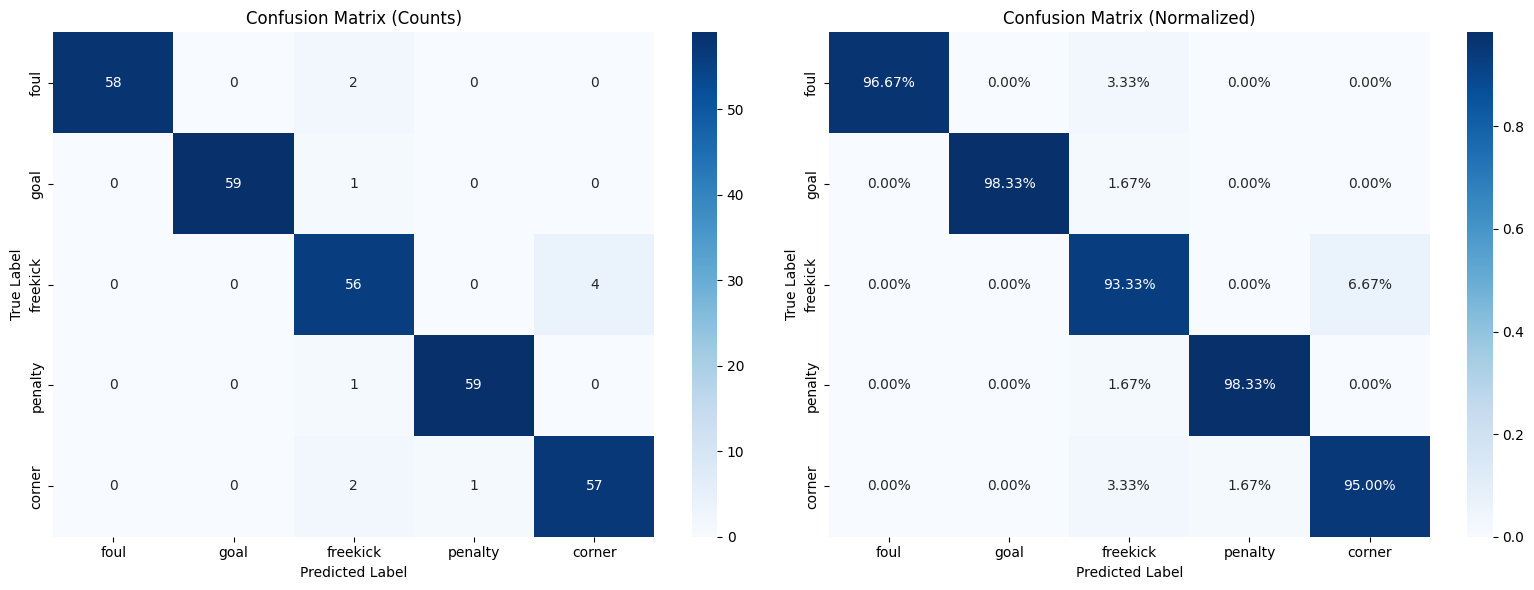

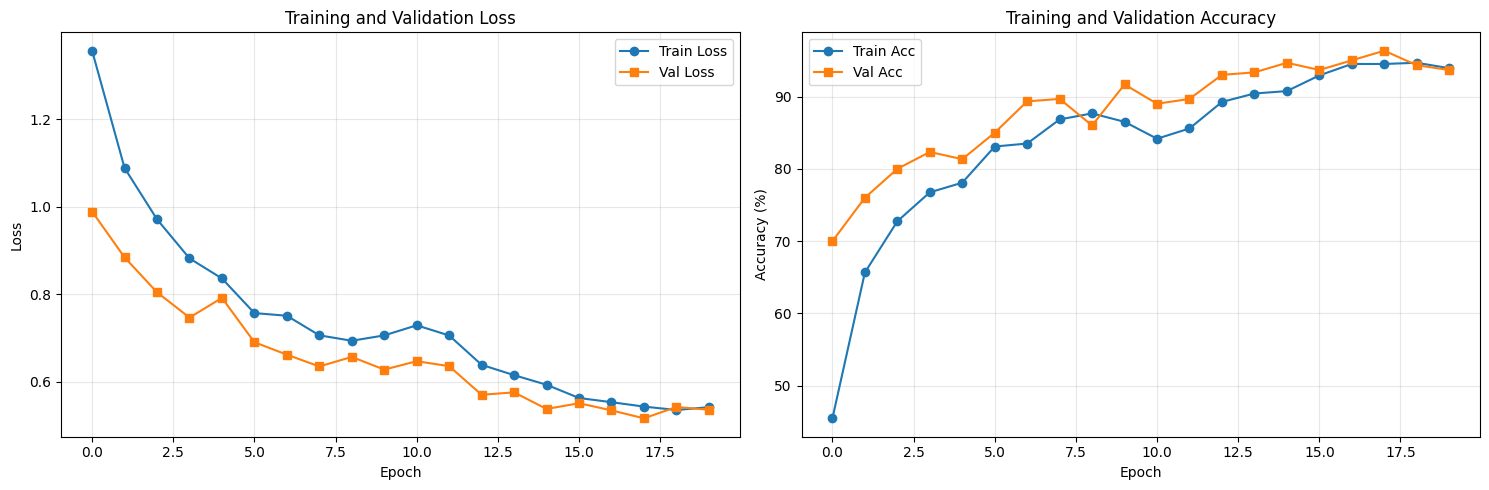


✓ Best validation accuracy: 96.33%
✓ Model saved to: best_video_swin_model.pth


In [3]:
# CUDA Memory Optimization Settings
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'max_split_size_mb:128'

CONFIG = {
    'data_path': '/kaggle/input/highlights',
    'model_name': 'swin_small_patch4_window7_224',
    'num_classes': 5,
    'batch_size': 2,  # REDUCED from 8 to save memory
    'gradient_accumulation_steps': 16,  # INCREASED from 4 to maintain effective batch size of 32
    'num_epochs': 20,
    'learning_rate': 5e-5,
    'weight_decay': 0.01,
    'warmup_ratio': 0.1,
    'num_frames': 60,
    'img_size': 224,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'num_workers': 2,
    'save_path': 'best_video_swin_model.pth',
    'mixed_precision': True,
    'early_stopping_patience': 3,
    'gradient_clipping': 1.0,
    'label_smoothing': 0.1,
    'dropout': 0.3,
    'freeze_backbone_epochs': 2,
    'videos_per_class': 300,
}


def clear_memory():
    """Clear CUDA cache and garbage collect"""
    torch.cuda.empty_cache()
    gc.collect()


class VideoDataset(Dataset):
    """Memory-optimized Dataset for Video Swin Transformer"""
    
    def __init__(self, video_paths, labels, num_frames=16, img_size=224, mode='train'):
        self.video_paths = video_paths
        self.labels = labels
        self.num_frames = num_frames
        self.img_size = img_size
        self.mode = mode
        
        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
        
        if mode == 'train':
            self.spatial_transform = transforms.Compose([
                transforms.ToPILImage(),
                transforms.RandomResizedCrop(img_size, scale=(0.8, 1.0)),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
                transforms.ToTensor(),
            ])
        else:
            self.spatial_transform = transforms.Compose([
                transforms.ToPILImage(),
                transforms.Resize((img_size, img_size)),
                transforms.ToTensor(),
            ])
        
    def __len__(self):
        return len(self.video_paths)
    
    def extract_frames(self, video_path):
        """Memory-efficient frame extraction"""
        cap = cv2.VideoCapture(video_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        if total_frames < self.num_frames:
            indices = np.linspace(0, total_frames - 1, total_frames, dtype=int)
            indices = np.tile(indices, self.num_frames // len(indices) + 1)[:self.num_frames]
        else:
            indices = np.linspace(0, total_frames - 1, self.num_frames, dtype=int)
        
        frames = []
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                # Resize immediately to save memory
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = cv2.resize(frame, (self.img_size, self.img_size))
                frames.append(frame)
            else:
                if frames:
                    frames.append(frames[-1].copy())
        
        cap.release()
        
        while len(frames) < self.num_frames:
            frames.append(frames[-1].copy() if frames else np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8))
        
        return frames[:self.num_frames]
    
    def __getitem__(self, idx):
        video_path = self.video_paths[idx]
        label = self.labels[idx]
        
        frames = self.extract_frames(video_path)
        
        processed_frames = []
        for frame in frames:
            frame_tensor = self.spatial_transform(frame)
            frame_tensor = self.normalize(frame_tensor)
            processed_frames.append(frame_tensor)
        
        video_tensor = torch.stack(processed_frames)
        
        # Clear references
        del frames, processed_frames
        
        return video_tensor, label


class VideoSwinTransformer(nn.Module):
    """Memory-optimized Video Swin Transformer"""
    
    def __init__(self, model_name, num_classes, num_frames=16, dropout=0.3):
        super().__init__()
        self.num_frames = num_frames
        
        self.backbone = timm.create_model(
            model_name,
            pretrained=True,
            num_classes=0,
            global_pool=''
        )
        
        # Enable gradient checkpointing to save memory
        if hasattr(self.backbone, 'set_grad_checkpointing'):
            self.backbone.set_grad_checkpointing(enable=True)
        
        self.feature_dim = self.backbone.num_features
        
        self.temporal_pool = nn.AdaptiveAvgPool1d(1)
        
        self.temporal_conv = nn.Sequential(
            nn.Conv1d(self.feature_dim, self.feature_dim, kernel_size=3, padding=1),
            nn.BatchNorm1d(self.feature_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5)
        )
        
        self.lstm = nn.LSTM(
            input_size=self.feature_dim,
            hidden_size=self.feature_dim // 2,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=dropout * 0.5 if dropout > 0 else 0
        )
        
        self.temporal_attention = nn.MultiheadAttention(
            embed_dim=self.feature_dim,
            num_heads=8,
            dropout=dropout * 0.5,
            batch_first=True
        )
        
        self.classifier = nn.Sequential(
            nn.LayerNorm(self.feature_dim),
            nn.Dropout(dropout),
            nn.Linear(self.feature_dim, self.feature_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(self.feature_dim // 2, num_classes)
        )
        
    def forward(self, x):
        batch_size, num_frames, c, h, w = x.shape
        
        x = x.view(batch_size * num_frames, c, h, w)
        
        features = self.backbone(x)
        
        if len(features.shape) == 4:
            features = features.mean(dim=[1, 2])
        
        features = features.view(batch_size, num_frames, -1)
        
        temp_conv_out = self.temporal_conv(features.transpose(1, 2))
        temp_conv_out = temp_conv_out.transpose(1, 2)
        
        lstm_out, _ = self.lstm(temp_conv_out)
        
        attended_features, _ = self.temporal_attention(
            lstm_out, lstm_out, lstm_out
        )
        
        combined_features = lstm_out + attended_features
        
        video_features = combined_features.mean(dim=1)
        
        logits = self.classifier(video_features)
        
        return logits


def load_data(data_path):
    """Load video paths and labels - exactly 300 per class"""
    classes = ['foul', 'goal', 'freekick', 'penalty', 'corner']
    class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
    target_videos_per_class = CONFIG['videos_per_class']
    
    video_paths = []
    labels = []
    
    for cls in classes:
        cls_path = os.path.join(data_path, cls)
        if not os.path.exists(cls_path):
            print(f"Warning: {cls_path} does not exist")
            continue
            
        video_files = [f for f in os.listdir(cls_path) if f.endswith(('.mp4', '.avi', '.mov'))]
        num_videos = len(video_files)
        print(f"{cls}: Found {num_videos} videos")
        
        if num_videos >= target_videos_per_class:
            selected_files = np.random.choice(video_files, target_videos_per_class, replace=False).tolist()
        else:
            selected_files = video_files + list(np.random.choice(
                video_files, target_videos_per_class - num_videos, replace=True
            ))
        
        for video_file in selected_files:
            video_paths.append(os.path.join(cls_path, video_file))
            labels.append(class_to_idx[cls])
        
        print(f"{cls}: Selected {len([l for l in labels if l == class_to_idx[cls]])} videos")
    
    print(f"\nTotal videos: {len(video_paths)} ({target_videos_per_class} per class)")
    return video_paths, labels, classes


def train_epoch(model, dataloader, criterion, optimizer, scheduler, device, scaler=None, accum_steps=1, epoch=0):
    """Memory-optimized training loop"""
    model.train()
    
    if epoch < CONFIG.get('freeze_backbone_epochs', 0):
        for param in model.backbone.parameters():
            param.requires_grad = False
    else:
        for param in model.backbone.parameters():
            param.requires_grad = True
    
    total_loss = 0
    correct = 0
    total = 0
    
    optimizer.zero_grad()
    
    pbar = tqdm(dataloader, desc='Training')
    for batch_idx, (videos, labels) in enumerate(pbar):
        videos = videos.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        if scaler is not None:
            with torch.amp.autocast('cuda'):
                outputs = model(videos)
                loss = criterion(outputs, labels) / accum_steps
            
            scaler.scale(loss).backward()
            
            if (batch_idx + 1) % accum_steps == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG['gradient_clipping'])
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
                scheduler.step()
                
                # Clear memory periodically
                if (batch_idx + 1) % (accum_steps * 4) == 0:
                    clear_memory()
        else:
            outputs = model(videos)
            loss = criterion(outputs, labels) / accum_steps
            loss.backward()
            
            if (batch_idx + 1) % accum_steps == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG['gradient_clipping'])
                optimizer.step()
                optimizer.zero_grad()
                scheduler.step()
        
        total_loss += loss.item() * accum_steps
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        # Clear batch tensors
        del videos, labels, outputs, loss
        
        pbar.set_postfix({
            'loss': f'{total_loss / (batch_idx + 1):.3f}',
            'acc': f'{100. * correct / total:.1f}%'
        })
    
    clear_memory()
    return total_loss / len(dataloader), 100. * correct / total


def validate(model, dataloader, criterion, device):
    """Memory-optimized validation loop"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for videos, labels in tqdm(dataloader, desc='Validation'):
            videos = videos.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            outputs = model(videos)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            # Clear batch tensors
            del videos, labels, outputs, loss
    
    clear_memory()
    return total_loss / len(dataloader), 100. * correct / total, all_preds, all_labels


def plot_confusion_matrix(y_true, y_pred, classes, save_path='confusion_matrix.png'):
    """Enhanced confusion matrix visualization"""
    cm = confusion_matrix(y_true, y_pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
                xticklabels=classes, yticklabels=classes)
    ax1.set_title('Confusion Matrix (Counts)')
    ax1.set_ylabel('True Label')
    ax1.set_xlabel('Predicted Label')
    
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', ax=ax2,
                xticklabels=classes, yticklabels=classes)
    ax2.set_title('Confusion Matrix (Normalized)')
    ax2.set_ylabel('True Label')
    ax2.set_xlabel('Predicted Label')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()


def main():
    clear_memory()
    
    torch.manual_seed(42)
    np.random.seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(42)
    
    print(f"Using device: {CONFIG['device']}")
    if CONFIG['device'] == 'cuda':
        print(f"GPU: {torch.cuda.get_device_name(0)}")
        print(f"Available memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    
    video_paths, labels, classes = load_data(CONFIG['data_path'])
    
    train_paths, val_paths, train_labels, val_labels = train_test_split(
        video_paths, labels, test_size=0.2, random_state=42, stratify=labels
    )
    
    print(f"\nDataset Split:")
    print(f"Train: {len(train_paths)} videos")
    print(f"Val: {len(val_paths)} videos")
    
    train_dataset = VideoDataset(train_paths, train_labels, 
                                CONFIG['num_frames'], CONFIG['img_size'], mode='train')
    val_dataset = VideoDataset(val_paths, val_labels,
                              CONFIG['num_frames'], CONFIG['img_size'], mode='val')
    
    # Memory-optimized dataloaders
    train_loader = DataLoader(
        train_dataset, 
        batch_size=CONFIG['batch_size'],
        shuffle=True, 
        num_workers=CONFIG['num_workers'],
        pin_memory=True, 
        prefetch_factor=2,
        persistent_workers=False,  # Changed to False to save memory
        drop_last=True
    )
    val_loader = DataLoader(
        val_dataset, 
        batch_size=CONFIG['batch_size'],
        shuffle=False, 
        num_workers=CONFIG['num_workers'],
        pin_memory=True, 
        prefetch_factor=2,
        persistent_workers=False,  # Changed to False to save memory
        drop_last=False
    )
    
    print(f"\nLoading {CONFIG['model_name']}...")
    model = VideoSwinTransformer(
        CONFIG['model_name'], 
        CONFIG['num_classes'], 
        CONFIG['num_frames'],
        CONFIG['dropout']
    ).to(CONFIG['device'])
    
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    
    criterion = nn.CrossEntropyLoss(label_smoothing=CONFIG['label_smoothing'])
    
    optimizer = torch.optim.AdamW([
        {'params': model.backbone.parameters(), 'lr': CONFIG['learning_rate'] * 0.1},
        {'params': model.temporal_conv.parameters(), 'lr': CONFIG['learning_rate']},
        {'params': model.lstm.parameters(), 'lr': CONFIG['learning_rate']},
        {'params': model.temporal_attention.parameters(), 'lr': CONFIG['learning_rate']},
        {'params': model.classifier.parameters(), 'lr': CONFIG['learning_rate'] * 2},
    ], weight_decay=CONFIG['weight_decay'])
    
    total_steps = (len(train_loader) // CONFIG['gradient_accumulation_steps']) * CONFIG['num_epochs']
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=total_steps // 2, T_mult=1, eta_min=1e-8
    )
    
    scaler = torch.amp.GradScaler('cuda') if CONFIG['mixed_precision'] and CONFIG['device'] == 'cuda' else None
    
    best_acc = 0
    early_stop_counter = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(CONFIG['num_epochs']):
        print(f"\n{'='*50}")
        print(f"Epoch {epoch + 1}/{CONFIG['num_epochs']}")
        print(f"{'='*50}")
        
        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer, scheduler, 
            CONFIG['device'], scaler, CONFIG['gradient_accumulation_steps'], epoch
        )
        
        clear_memory()
        
        val_loss, val_acc, val_preds, val_labels_list = validate(
            model, val_loader, criterion, CONFIG['device']
        )
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'config': CONFIG
            }, CONFIG['save_path'])
            print(f"✓ Saved best model with accuracy: {best_acc:.2f}%")
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            if early_stop_counter >= CONFIG['early_stopping_patience']:
                print("Early stopping triggered")
                break
        
        clear_memory()
    
    checkpoint = torch.load(CONFIG['save_path'])
    model.load_state_dict(checkpoint['model_state_dict'])
    
    _, _, final_preds, final_labels = validate(model, val_loader, criterion, CONFIG['device'])
    
    print("\n" + "="*50)
    print("FINAL EVALUATION")
    print("="*50)
    print(classification_report(final_labels, final_preds, target_names=classes, digits=4))
    plot_confusion_matrix(final_labels, final_preds, classes)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    ax1.plot(history['train_loss'], label='Train Loss', marker='o')
    ax1.plot(history['val_loss'], label='Val Loss', marker='s')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_title('Training and Validation Loss')
    
    ax2.plot(history['train_acc'], label='Train Acc', marker='o')
    ax2.plot(history['val_acc'], label='Val Acc', marker='s')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_title('Training and Validation Accuracy')
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300)
    plt.show()
    
    print(f"\n✓ Best validation accuracy: {best_acc:.2f}%")
    print(f"✓ Model saved to: {CONFIG['save_path']}")


if __name__ == "__main__":
    main()

In [4]:
# import tensorflow as tf
# from numba import cuda
# import gc

# # Clear TF session (works in TF 2.x)
# tf.keras.backend.clear_session()

# # Close CUDA device
# cuda.select_device(0)
# cuda.close()

# # Run garbage collection
# gc.collect()

In [5]:
# !nvidia-smi

In [6]:
# import os
# os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [7]:
# import cv2
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import gc
# import numpy as np
# from torchvision import transforms
# import timm

# # Configuration matching the training script
# CONFIG = {
#     'model_name': 'swin_small_patch4_window7_224',
#     'num_classes': 5,
#     'num_frames': 16,  # Must match training config
#     'img_size': 224,
#     'mixed_precision': True,
#     'dropout': 0.3,
# }


# class VideoSwinTransformer(nn.Module):
#     """Same architecture as training - must match exactly"""
    
#     def __init__(self, model_name, num_classes, num_frames=16, dropout=0.3):
#         super().__init__()
#         self.num_frames = num_frames
        
#         # Load pretrained Swin Transformer
#         self.backbone = timm.create_model(
#             model_name,
#             pretrained=True,
#             num_classes=0,
#             global_pool=''
#         )
        
#         self.feature_dim = self.backbone.num_features
        
#         # Temporal modeling layers
#         self.temporal_pool = nn.AdaptiveAvgPool1d(1)
        
#         self.temporal_conv = nn.Sequential(
#             nn.Conv1d(self.feature_dim, self.feature_dim, kernel_size=3, padding=1),
#             nn.BatchNorm1d(self.feature_dim),
#             nn.ReLU(inplace=True),
#             nn.Dropout(dropout * 0.5)
#         )
        
#         self.lstm = nn.LSTM(
#             input_size=self.feature_dim,
#             hidden_size=self.feature_dim // 2,
#             num_layers=2,
#             batch_first=True,
#             bidirectional=True,
#             dropout=dropout * 0.5 if dropout > 0 else 0
#         )
        
#         self.temporal_attention = nn.MultiheadAttention(
#             embed_dim=self.feature_dim,
#             num_heads=8,
#             dropout=dropout * 0.5,
#             batch_first=True
#         )
        
#         self.classifier = nn.Sequential(
#             nn.LayerNorm(self.feature_dim),
#             nn.Dropout(dropout),
#             nn.Linear(self.feature_dim, self.feature_dim // 2),
#             nn.GELU(),
#             nn.Dropout(dropout * 0.5),
#             nn.Linear(self.feature_dim // 2, num_classes)
#         )
        
#     def forward(self, x):
#         # x: [B, T, C, H, W]
#         batch_size, num_frames, c, h, w = x.shape
#         x = x.view(batch_size * num_frames, c, h, w)
        
#         # Extract spatial features
#         features = self.backbone(x)
        
#         if len(features.shape) == 4:
#             features = features.mean(dim=[1, 2])
        
#         features = features.view(batch_size, num_frames, -1)
        
#         # Temporal convolution
#         temp_conv_out = self.temporal_conv(features.transpose(1, 2))
#         temp_conv_out = temp_conv_out.transpose(1, 2)
        
#         # LSTM
#         lstm_out, _ = self.lstm(temp_conv_out)
        
#         # Temporal attention
#         attended_features, _ = self.temporal_attention(
#             lstm_out, lstm_out, lstm_out
#         )
        
#         # Combine features
#         combined_features = lstm_out + attended_features
        
#         # Temporal pooling
#         video_features = combined_features.mean(dim=1)
        
#         # Classification
#         logits = self.classifier(video_features)
        
#         return logits


# def predict_consecutive_chunks_gpu(video_path, model_path, chunk_size=30, threshold=0.7):
#     """
#     Load the trained Video Swin model and make predictions on consecutive chunks
#     from the input video using GPU.
    
#     Args:
#         video_path (str): Path to the input video file.
#         model_path (str): Path to the saved model checkpoint.
#         chunk_size (int): Number of frames per chunk (default: 30).
#         threshold (float): Probability threshold to consider it an event (default: 0.7).
#     """
#     # Verify GPU availability
#     if not torch.cuda.is_available():
#         print("Warning: GPU not available. Using CPU (will be slower).")
#         device = 'cpu'
#     else:
#         device = 'cuda'
#         print(f"✓ Using GPU: {torch.cuda.get_device_name(0)}")
#         print(f"✓ Available GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

#     print(f"\n{'='*60}")
#     print("LOADING MODEL")
#     print(f"{'='*60}")
    
#     # Load model
#     model = VideoSwinTransformer(
#         CONFIG['model_name'], 
#         CONFIG['num_classes'], 
#         CONFIG['num_frames'],
#         CONFIG['dropout']
#     )
    
#     checkpoint = torch.load(model_path, map_location=device)
#     model.load_state_dict(checkpoint['model_state_dict'])
#     model.to(device)
#     model.eval()
    
#     print(f"✓ Model loaded from: {model_path}")
#     print(f"✓ Best validation accuracy: {checkpoint.get('val_acc', 'N/A'):.2f}%")
    
#     # Preprocessing transforms (same as training)
#     normalize = transforms.Normalize(
#         mean=[0.485, 0.456, 0.406],
#         std=[0.229, 0.224, 0.225]
#     )
    
#     transform = transforms.Compose([
#         transforms.ToPILImage(),
#         transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
#         transforms.ToTensor(),
#     ])
    
#     # Class names
#     classes = ['foul', 'goal', 'freekick', 'penalty', 'corner']
    
#     print(f"\n{'='*60}")
#     print("PROCESSING VIDEO")
#     print(f"{'='*60}")
    
#     # Open video
#     cap = cv2.VideoCapture(video_path)
#     if not cap.isOpened():
#         print(f"Error: Could not open video {video_path}")
#         return
    
#     # Get video properties
#     fps = cap.get(cv2.CAP_PROP_FPS)
#     total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
#     width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
#     height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
#     video_duration = total_frames / fps if fps > 0 else 0
    
#     print(f"Video: {video_path}")
#     print(f"Resolution: {width}x{height}")
#     print(f"FPS: {fps:.2f}")
#     print(f"Total frames: {total_frames}")
#     print(f"Duration: {video_duration:.2f} seconds")
#     print(f"Processing in chunks of {chunk_size} frames")
#     print(f"Model expects {CONFIG['num_frames']} frames per prediction")
#     print(f"Confidence threshold: {threshold}")
    
#     print(f"\n{'='*60}")
#     print("PREDICTIONS")
#     print(f"{'='*60}")
    
#     chunk_count = 0
#     event_count = 0
    
#     with torch.no_grad():
#         while cap.isOpened():
#             chunk_count += 1
#             start_frame = (chunk_count - 1) * chunk_size
#             end_frame = min(start_frame + chunk_size, total_frames)
            
#             if start_frame >= total_frames:
#                 break
            
#             # Extract chunk_size frames
#             frames = []
#             for idx in range(start_frame, end_frame):
#                 cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
#                 ret, frame = cap.read()
#                 if ret:
#                     frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#                     frames.append(frame)
            
#             if not frames:
#                 break
            
#             # Resample to exactly CONFIG['num_frames'] frames
#             num_extracted = len(frames)
#             if num_extracted < CONFIG['num_frames']:
#                 # Pad by repeating last frame
#                 while len(frames) < CONFIG['num_frames']:
#                     frames.append(frames[-1])
#             elif num_extracted > CONFIG['num_frames']:
#                 # Uniformly sample CONFIG['num_frames'] frames
#                 indices = np.linspace(0, num_extracted - 1, CONFIG['num_frames'], dtype=int)
#                 frames = [frames[i] for i in indices]
            
#             # Process frames
#             processed_frames = []
#             for frame in frames:
#                 frame_tensor = transform(frame)
#                 frame_tensor = normalize(frame_tensor)
#                 processed_frames.append(frame_tensor)
            
#             # Stack frames: (1, T, C, H, W)
#             frame_tensor = torch.stack(processed_frames).unsqueeze(0).to(device)
            
#             # Forward pass with mixed precision
#             if CONFIG['mixed_precision'] and device == 'cuda':
#                 with torch.amp.autocast('cuda'):
#                     logits = model(frame_tensor)
#             else:
#                 logits = model(frame_tensor)
            
#             # Compute probabilities
#             probs = F.softmax(logits, dim=1)[0]
#             max_prob, pred_idx = torch.max(probs, dim=0)
#             pred_class = classes[pred_idx.item()]
            
#             # Calculate time stamps
#             start_time = start_frame / fps if fps > 0 else 0
#             end_time = min(end_frame / fps, video_duration) if fps > 0 else 0
            
#             # Print prediction
#             if max_prob.item() >= threshold:
#                 print(f"🎯 Chunk {chunk_count:3d} | {start_time:6.2f}s - {end_time:6.2f}s | "
#                       f"Frames {start_frame+1:5d}-{end_frame:5d} | "
#                       f"Event: {pred_class.upper():10s} | Confidence: {max_prob.item():.1%}")
#                 event_count += 1
#             else:
#                 print(f"⚪ Chunk {chunk_count:3d} | {start_time:6.2f}s - {end_time:6.2f}s | "
#                       f"Frames {start_frame+1:5d}-{end_frame:5d} | "
#                       f"No event (max: {max_prob.item():.1%})")
            
#             # Show all class probabilities for events
#             if max_prob.item() >= threshold:
#                 print(f"   └─ Probabilities: ", end="")
#                 for i, cls in enumerate(classes):
#                     print(f"{cls}: {probs[i].item():.1%}", end="  ")
#                 print()
            
#             # Clear GPU cache periodically
#             if chunk_count % 10 == 0 and device == 'cuda':
#                 torch.cuda.empty_cache()
#                 gc.collect()
    
#     cap.release()
    
#     print(f"\n{'='*60}")
#     print("SUMMARY")
#     print(f"{'='*60}")
#     print(f"Total chunks processed: {chunk_count}")
#     print(f"Total frames processed: {total_frames}")
#     print(f"Events detected (≥{threshold:.0%} confidence): {event_count}")
#     print(f"Event rate: {event_count/chunk_count*100:.1f}% of chunks")
#     print("✓ Prediction complete!")
#     print(f"{'='*60}")


# def predict_single_video(video_path, model_path):
#     """
#     Make a single prediction on the entire video (sampling to CONFIG['num_frames']).
#     Useful for short clips or highlight videos.
    
#     Args:
#         video_path (str): Path to the input video file.
#         model_path (str): Path to the saved model checkpoint.
#     """
#     device = 'cuda' if torch.cuda.is_available() else 'cpu'
#     print(f"Using device: {device}")
    
#     # Load model
#     model = VideoSwinTransformer(
#         CONFIG['model_name'], 
#         CONFIG['num_classes'], 
#         CONFIG['num_frames'],
#         CONFIG['dropout']
#     )
    
#     checkpoint = torch.load(model_path, map_location=device)
#     model.load_state_dict(checkpoint['model_state_dict'])
#     model.to(device)
#     model.eval()
    
#     # Preprocessing
#     normalize = transforms.Normalize(
#         mean=[0.485, 0.456, 0.406],
#         std=[0.229, 0.224, 0.225]
#     )
    
#     transform = transforms.Compose([
#         transforms.ToPILImage(),
#         transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
#         transforms.ToTensor(),
#     ])
    
#     classes = ['foul', 'goal', 'freekick', 'penalty']
    
#     # Open video and extract frames
#     cap = cv2.VideoCapture(video_path)
#     total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
#     fps = cap.get(cv2.CAP_PROP_FPS)
    
#     print(f"\nProcessing: {video_path}")
#     print(f"Total frames: {total_frames}, FPS: {fps:.2f}")
    
#     # Sample frames uniformly
#     indices = np.linspace(0, total_frames - 1, CONFIG['num_frames'], dtype=int)
#     frames = []
    
#     for idx in indices:
#         cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
#         ret, frame = cap.read()
#         if ret:
#             frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#             frames.append(frame)
    
#     cap.release()
    
#     if len(frames) < CONFIG['num_frames']:
#         while len(frames) < CONFIG['num_frames']:
#             frames.append(frames[-1])
    
#     # Process frames
#     processed_frames = []
#     for frame in frames:
#         frame_tensor = transform(frame)
#         frame_tensor = normalize(frame_tensor)
#         processed_frames.append(frame_tensor)
    
#     frame_tensor = torch.stack(processed_frames).unsqueeze(0).to(device)
    
#     # Predict
#     with torch.no_grad():
#         if CONFIG['mixed_precision'] and device == 'cuda':
#             with torch.amp.autocast('cuda'):
#                 logits = model(frame_tensor)
#         else:
#             logits = model(frame_tensor)
        
#         probs = F.softmax(logits, dim=1)[0]
#         max_prob, pred_idx = torch.max(probs, dim=0)
#         pred_class = classes[pred_idx.item()]
    
#     print(f"\n{'='*60}")
#     print(f"PREDICTION: {pred_class.upper()}")
#     print(f"Confidence: {max_prob.item():.1%}")
#     print(f"{'='*60}")
#     print("All class probabilities:")
#     for i, cls in enumerate(classes):
#         print(f"  {cls:10s}: {probs[i].item():.1%} {'█' * int(probs[i].item() * 50)}")
#     print(f"{'='*60}")


# def predict_with_sliding_window(video_path, model_path, window_size=16, stride=8, threshold=0.7):
#     """
#     Make predictions using a sliding window approach for more granular detection.
    
#     Args:
#         video_path (str): Path to the input video file.
#         model_path (str): Path to the saved model checkpoint.
#         window_size (int): Number of frames per window (should match CONFIG['num_frames']).
#         stride (int): Number of frames to slide the window (smaller = more overlap).
#         threshold (float): Probability threshold to consider it an event.
#     """
#     device = 'cuda' if torch.cuda.is_available() else 'cpu'
#     print(f"✓ Using device: {device}")
    
#     # Load model
#     model = VideoSwinTransformer(
#         CONFIG['model_name'], 
#         CONFIG['num_classes'], 
#         CONFIG['num_frames'],
#         CONFIG['dropout']
#     )
    
#     checkpoint = torch.load(model_path, map_location=device)
#     model.load_state_dict(checkpoint['model_state_dict'])
#     model.to(device)
#     model.eval()
    
#     print(f"✓ Model loaded with accuracy: {checkpoint.get('val_acc', 'N/A'):.2f}%")
    
#     # Preprocessing
#     normalize = transforms.Normalize(
#         mean=[0.485, 0.456, 0.406],
#         std=[0.229, 0.224, 0.225]
#     )
    
#     transform = transforms.Compose([
#         transforms.ToPILImage(),
#         transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
#         transforms.ToTensor(),
#     ])
    
#     classes = ['foul', 'goal', 'freekick', 'penalty']
    
#     # Open video
#     cap = cv2.VideoCapture(video_path)
#     total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
#     fps = cap.get(cv2.CAP_PROP_FPS)
    
#     print(f"\n{'='*60}")
#     print("SLIDING WINDOW PREDICTION")
#     print(f"{'='*60}")
#     print(f"Video: {video_path}")
#     print(f"Total frames: {total_frames}, FPS: {fps:.2f}")
#     print(f"Window size: {window_size}, Stride: {stride}")
#     print(f"Threshold: {threshold}")
#     print(f"{'='*60}\n")
    
#     event_count = 0
#     window_count = 0
    
#     with torch.no_grad():
#         for start_idx in range(0, total_frames - window_size + 1, stride):
#             window_count += 1
#             end_idx = start_idx + window_size
            
#             # Extract frames for this window
#             frames = []
#             for idx in range(start_idx, end_idx):
#                 cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
#                 ret, frame = cap.read()
#                 if ret:
#                     frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#                     frames.append(frame)
            
#             if len(frames) < window_size:
#                 continue
            
#             # Process frames
#             processed_frames = []
#             for frame in frames:
#                 frame_tensor = transform(frame)
#                 frame_tensor = normalize(frame_tensor)
#                 processed_frames.append(frame_tensor)
            
#             frame_tensor = torch.stack(processed_frames).unsqueeze(0).to(device)
            
#             # Predict
#             if CONFIG['mixed_precision'] and device == 'cuda':
#                 with torch.amp.autocast('cuda'):
#                     logits = model(frame_tensor)
#             else:
#                 logits = model(frame_tensor)
            
#             probs = F.softmax(logits, dim=1)[0]
#             max_prob, pred_idx = torch.max(probs, dim=0)
#             pred_class = classes[pred_idx.item()]
            
#             start_time = start_idx / fps
#             end_time = end_idx / fps
            
#             if max_prob.item() >= threshold:
#                 print(f"🎯 Window {window_count:3d} | {start_time:6.2f}s - {end_time:6.2f}s | "
#                       f"Event: {pred_class.upper():10s} | Confidence: {max_prob.item():.1%}")
#                 event_count += 1
            
#             # Clear cache periodically
#             if window_count % 20 == 0 and device == 'cuda':
#                 torch.cuda.empty_cache()
    
#     cap.release()
    
#     print(f"\n{'='*60}")
#     print(f"Total windows: {window_count}")
#     print(f"Events detected: {event_count}")
#     print(f"{'='*60}")


# # Example usage
# if __name__ == "__main__":
#     # Option 1: Process video in chunks (recommended for long videos)
#     # print("="*60)
#     # print("OPTION 1: CHUNK-BASED PREDICTION")
#     # print("="*60)
#     # predict_consecutive_chunks_gpu(
#     #     video_path='/kaggle/input/foullll/Mane SCISSOR TACKLE against RVP.mp4',
#     #     model_path='/kaggle/input/swin-model/best_video_swin_model.pth',
#     #     chunk_size=30,
#     #     threshold=0.7
#     # )
    
#     # Option 2: Single prediction for entire video (better for short clips)
#     print("\n" + "="*60)
#     print("OPTION 2: SINGLE VIDEO PREDICTION")

#     print("="*60)
#     predict_single_video(
#         video_path='/kaggle/input/foullll/Mane SCISSOR TACKLE against RVP.mp4',
#         model_path='/kaggle/input/swisss/best_video_swin_model (1).pth'
#     )
    
#     # Option 3: Sliding window with overlap (most thorough)
#     # print("\n" + "="*60)
#     # print("OPTION 3: SLIDING WINDOW PREDICTION")
#     # print("="*60)
#     # predict_with_sliding_window(
#     #     video_path='/kaggle/input/foullll/Mane SCISSOR TACKLE against RVP.mp4',
#     #     model_path='/kaggle/input/swin-model/best_video_swin_model.pth',
#     #     window_size=16,  # Match CONFIG['num_frames']
#     #     stride=8,        # 50% overlap
#     #     threshold=0.7
#     # )